In [34]:
import pandas as pd 
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder,RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

## Dataset Load

In [2]:
df = pd.read_csv("gym_members_exercise_tracking.csv")

## Feature Enginnering

In [3]:
def bmi_category(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif bmi < 25:
        return 'Normal'
    elif bmi < 30:
        return 'Overweight'
    else:
        return 'Obese'

df['BMI_Category'] = df['BMI'].apply(bmi_category)

In [4]:
df['Heart_Rate_Reserve'] = df['Max_BPM'] - df['Resting_BPM']

In [5]:
df['HR_Intensity'] = df['Avg_BPM'] / df['Max_BPM']

In [6]:
def intensity_category(value):
    if value < 0.70:
        return 'Low'
    elif value < 0.85:
        return 'Moderate'
    else:
        return 'High'

df['Workout_Intensity'] = df['HR_Intensity'].apply(intensity_category)

In [7]:
df['Calories_Per_Hour'] = (df['Calories_Burned'] / df['Session_Duration (hours)']) 

In [8]:
df['Workout_Load'] = (df['Session_Duration (hours)'] * df['Avg_BPM'])

In [9]:
df['Weekly_Workout_Hours'] = (df['Workout_Frequency (days/week)']* df['Session_Duration (hours)'])

In [10]:
df['Risk_Score'] = 0

df.loc[df['BMI'] >= 30, 'Risk_Score'] += 1
df.loc[df['Fat_Percentage'] >= 30, 'Risk_Score'] += 1
df.loc[df['HR_Intensity'] >= 0.85, 'Risk_Score'] += 1
df.loc[df['Resting_BPM'] >= 70, 'Risk_Score'] += 1
df.loc[df['Workout_Load'] >= 200, 'Risk_Score'] += 1

In [11]:
def fitness_risk(score):

    if score <= 1:
        return 'Low'

    elif score == 2:
        return 'Moderate'

    else:
        return 'High'


df['Fitness_Risk'] = df['Risk_Score'].apply(fitness_risk)

In [12]:
df.head().T

,0,1,2,3,4
Age,56,46,32,25,38
Gender,Male,Female,Female,Male,Male
Weight (kg),88.3,74.9,68.1,53.2,46.1
Height (m),1.71,1.53,1.66,1.7,1.79
Max_BPM,180,179,167,190,188
Avg_BPM,157,151,122,164,158
Resting_BPM,60,66,54,56,68
Session_Duration (hours),1.69,1.3,1.11,0.59,0.64
Calories_Burned,1313.0,883.0,677.0,532.0,556.0
Workout_Type,Yoga,HIIT,Cardio,Strength,Strength


# Data Spliting

In [13]:
x = df.drop(['Fitness_Risk','Risk_Score', 'Calories_Burned','Calories_Per_Hour'], axis=1)

risk_mapping = {'Low': 0,'Moderate': 1,'High': 2}

y = df['Fitness_Risk'].map(risk_mapping)

## Performing Train Test Split

In [15]:
xtrain , xtest , ytrain , ytest = train_test_split(x,y,test_size = .25, random_state = 42)

## Encoding Apply


In [17]:
encoder = OneHotEncoder(sparse_output=False, drop='first')

categorical_columns = xtrain.select_dtypes(include='object').columns

for column in categorical_columns:

    train_encoded = encoder.fit_transform(xtrain[[column]])
    test_encoded = encoder.transform(xtest[[column]])

    train_df = pd.DataFrame(train_encoded,
                            columns=encoder.get_feature_names_out([column]),
                            index=xtrain.index)

    test_df = pd.DataFrame(test_encoded,
                           columns=encoder.get_feature_names_out([column]),
                           index=xtest.index)

    xtrain = pd.concat([xtrain, train_df], axis=1)
    xtest = pd.concat([xtest, test_df], axis=1)

    xtrain.drop(column, axis=1, inplace=True)
    xtest.drop(column, axis=1, inplace=True)

## Performing Random Forest Classifier 

Best Parameters For Random Forest:
{'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}


Training Score For Random Forest : 100.0
Testing Score For Random Forest : 95.08196721311475
Accuracy Score For Random Forest : 95.08196721311475


Classification Report For Random Forest:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       160
           1       0.94      0.84      0.89        58
           2       0.92      0.88      0.90        26

    accuracy                           0.95       244
   macro avg       0.94      0.91      0.92       244
weighted avg       0.95      0.95      0.95       244

Sensitivity : 0.909814323607427
Specificity : 0.9637877741606656
ROC-AUC Score : 0.9934780567883194




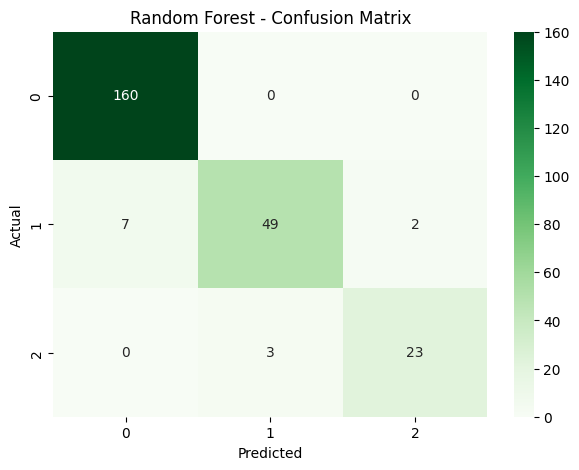

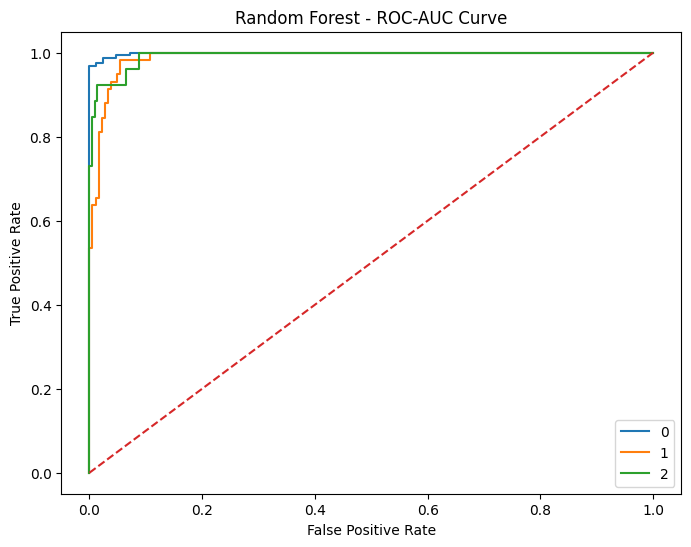

In [28]:
# Random Forest

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'max_features': ['sqrt', 'log2']
}

rf_grid = GridSearchCV(
    rf,
    rf_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

model_rf = rf_grid.fit(xtrain, ytrain)

# Best Parameters

print("Best Parameters For Random Forest:")
print(model_rf.best_params_)
print("\n")

# Training Score

print("Training Score For Random Forest :",
      model_rf.score(xtrain, ytrain) * 100)

# Testing Score

print("Testing Score For Random Forest :",
      model_rf.score(xtest, ytest) * 100)


# Predictions

ytest_pred = model_rf.predict(xtest)

# Accuracy Score

accuracy_rf = accuracy_score(ytest, ytest_pred)

print("Accuracy Score For Random Forest :",
      accuracy_rf * 100)

print("\n")

# Classification Report
print("Classification Report For Random Forest:")
print(classification_report(ytest, ytest_pred))



# Confusion Matrix
cm_rf = confusion_matrix(ytest, ytest_pred)



# Sensitivity
sensitivity_rf = recall_score(ytest,ytest_pred,average='macro')
print("Sensitivity :", sensitivity_rf)



# Specificity

specificity_list = []

for i in range(len(cm_rf)):

    true_negative = cm_rf.sum() - (
        cm_rf[i, :].sum()
        + cm_rf[:, i].sum()
        - cm_rf[i, i]
    )

    false_positive = cm_rf[:, i].sum() - cm_rf[i, i]

    specificity = true_negative / (
        true_negative + false_positive
    )

    specificity_list.append(specificity)

specificity_rf = np.mean(specificity_list)

print("Specificity :", specificity_rf)

# ROC-AUC Score

ytest_probability = model_rf.predict_proba(xtest)

roc_auc_rf = roc_auc_score(
    ytest,
    ytest_probability,
    multi_class='ovr',
    average='macro'
)

print("ROC-AUC Score :", roc_auc_rf)

print("\n")



# Confusion Matrix

plt.figure(figsize=(7, 5))
sns.heatmap(cm_rf,annot=True,fmt='d',cmap='Greens')
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# ROC-AUC Curve

ytest_binary = label_binarize(ytest, classes=model_rf.classes_)

plt.figure(figsize=(8, 6))

for i in range(len(model_rf.classes_)):

    fpr, tpr, _ = roc_curve(ytest_binary[:, i],ytest_probability[:, i])
    plt.plot(fpr,tpr,label=model_rf.classes_[i])

plt.plot([0, 1], [0, 1], '--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Random Forest - ROC-AUC Curve")

plt.legend()
plt.show()

## Performing ExtraTreeClassifier

Best Parameters For Extra Trees:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}


Training Score For Extra Trees : 100.0
Testing Score For Extra Trees : 85.65573770491804
Accuracy Score For Extra Trees : 85.65573770491804


Classification Report For Extra Trees:
              precision    recall  f1-score   support

           0       0.89      0.99      0.93       160
           1       0.78      0.55      0.65        58
           2       0.76      0.73      0.75        26

    accuracy                           0.86       244
   macro avg       0.81      0.76      0.78       244
weighted avg       0.85      0.86      0.85       244

Sensitivity : 0.7566644562334218
Specificity : 0.8953315764502506
ROC-AUC Score : 0.9464158337287311




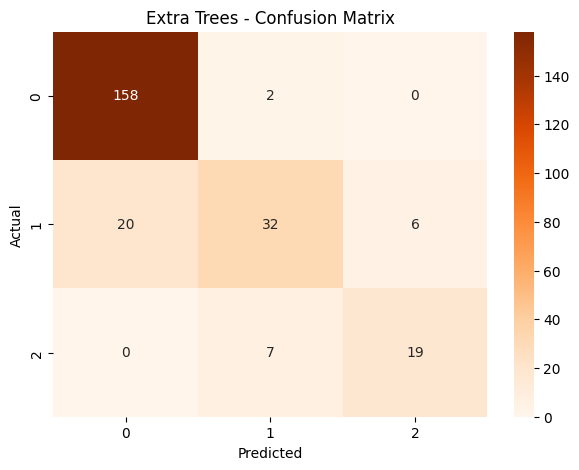

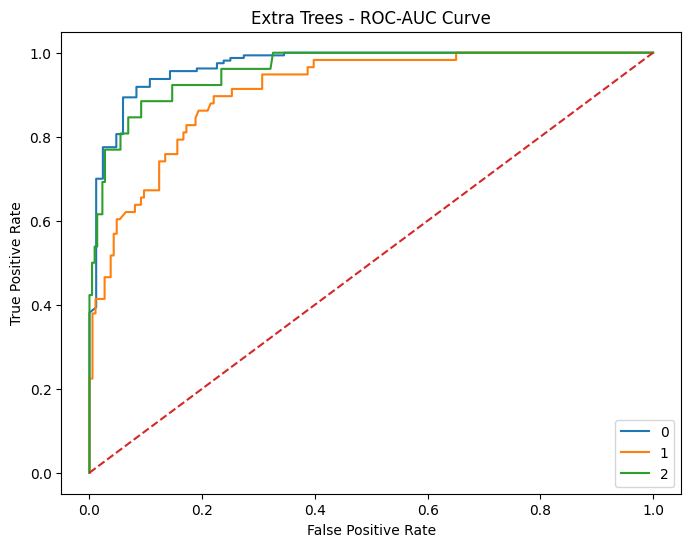

In [35]:
# Extra Trees

extra = ExtraTreesClassifier(
    random_state=42,
    n_jobs=-1
)

extra_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'max_features': ['sqrt', 'log2']
}

extra_grid = GridSearchCV(
    extra,
    extra_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

model_extra = extra_grid.fit(xtrain, ytrain)

# Best Parameters

print("Best Parameters For Extra Trees:")
print(model_extra.best_params_)
print("\n")

# Training Score

print("Training Score For Extra Trees :",
      model_extra.score(xtrain, ytrain) * 100)

# Testing Score

print("Testing Score For Extra Trees :",
      model_extra.score(xtest, ytest) * 100)

# Predictions

ytest_pred = model_extra.predict(xtest)

# Accuracy Score

accuracy_extra = accuracy_score(ytest, ytest_pred)

print("Accuracy Score For Extra Trees :",
      accuracy_extra * 100)

print("\n")

# Classification Report

print("Classification Report For Extra Trees:")
print(classification_report(ytest, ytest_pred))

# Confusion Matrix

cm_extra = confusion_matrix(ytest, ytest_pred)

# Sensitivity

sensitivity_extra = recall_score(
    ytest,
    ytest_pred,
    average='macro'
)

print("Sensitivity :", sensitivity_extra)

# Specificity

specificity_list = []

for i in range(len(cm_extra)):

    true_negative = cm_extra.sum() - (
        cm_extra[i, :].sum()
        + cm_extra[:, i].sum()
        - cm_extra[i, i]
    )

    false_positive = cm_extra[:, i].sum() - cm_extra[i, i]

    specificity = true_negative / (
        true_negative + false_positive
    )

    specificity_list.append(specificity)

specificity_extra = np.mean(specificity_list)

print("Specificity :", specificity_extra)

# ROC-AUC Score

ytest_probability = model_extra.predict_proba(xtest)

roc_auc_extra = roc_auc_score(
    ytest,
    ytest_probability,
    multi_class='ovr',
    average='macro'
)

print("ROC-AUC Score :", roc_auc_extra)

print("\n")

# Confusion Matrix

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_extra,
    annot=True,
    fmt='d',
    cmap='Oranges'
)

plt.title("Extra Trees - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC-AUC Curve

ytest_binary = label_binarize(
    ytest,
    classes=model_extra.classes_
)

plt.figure(figsize=(8, 6))

for i in range(len(model_extra.classes_)):

    fpr, tpr, _ = roc_curve(ytest_binary[:, i],ytest_probability[:, i])

    plt.plot(fpr, tpr,label=model_extra.classes_[i])

plt.plot([0, 1], [0, 1], '--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")


plt.title("Extra Trees - ROC-AUC Curve")

plt.legend()
plt.show()

## Performing Gradient Boosting

Best Parameters For Gradient Boosting:
{'learning_rate': 0.1, 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


Training Score For Gradient Boosting : 100.0
Testing Score For Gradient Boosting : 98.77049180327869
Accuracy Score For Gradient Boosting : 98.77049180327869


Classification Report For Gradient Boosting:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       160
           1       0.98      0.97      0.97        58
           2       0.96      0.96      0.96        26

    accuracy                           0.99       244
   macro avg       0.98      0.98      0.98       244
weighted avg       0.99      0.99      0.99       244

Sensitivity : 0.975685234305924
Specificity : 0.992710579348638
ROC-AUC Score : 0.9993999536151366




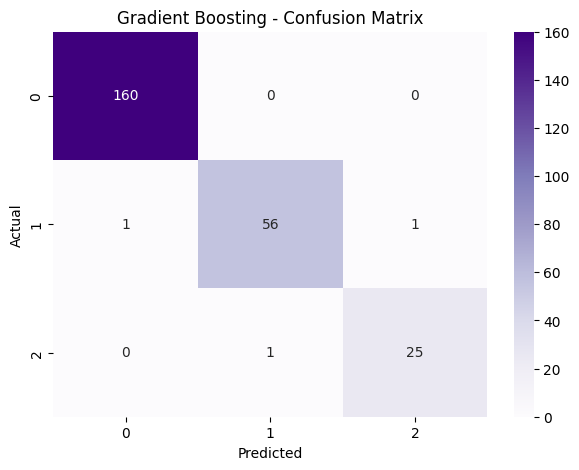

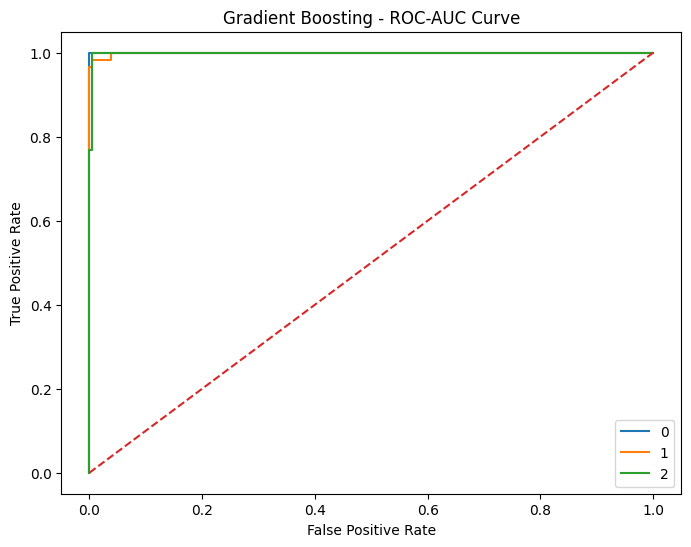

In [36]:
# Gradient Boosting

gb = GradientBoostingClassifier(
    random_state=42
)

gb_param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

gb_grid = GridSearchCV(
    gb,
    gb_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

model_gb = gb_grid.fit(xtrain, ytrain)

# Best Parameters

print("Best Parameters For Gradient Boosting:")
print(model_gb.best_params_)
print("\n")

# Training Score

print("Training Score For Gradient Boosting :",
      model_gb.score(xtrain, ytrain) * 100)

# Testing Score

print("Testing Score For Gradient Boosting :",
      model_gb.score(xtest, ytest) * 100)

# Predictions

ytest_pred = model_gb.predict(xtest)

# Accuracy Score

accuracy_gb = accuracy_score(ytest, ytest_pred)

print("Accuracy Score For Gradient Boosting :",
      accuracy_gb * 100)

print("\n")

# Classification Report

print("Classification Report For Gradient Boosting:")
print(classification_report(ytest, ytest_pred))

# Confusion Matrix

cm_gb = confusion_matrix(ytest, ytest_pred)

# Sensitivity

sensitivity_gb = recall_score(
    ytest,
    ytest_pred,
    average='macro'
)

print("Sensitivity :", sensitivity_gb)

# Specificity

specificity_list = []

for i in range(len(cm_gb)):

    true_negative = cm_gb.sum() - (
        cm_gb[i, :].sum()
        + cm_gb[:, i].sum()
        - cm_gb[i, i]
    )

    false_positive = cm_gb[:, i].sum() - cm_gb[i, i]

    specificity = true_negative / (
        true_negative + false_positive
    )

    specificity_list.append(specificity)

specificity_gb = np.mean(specificity_list)

print("Specificity :", specificity_gb)

# ROC-AUC Score

ytest_probability = model_gb.predict_proba(xtest)

roc_auc_gb = roc_auc_score(
    ytest,
    ytest_probability,
    multi_class='ovr',
    average='macro'
)

print("ROC-AUC Score :", roc_auc_gb)

print("\n")

# Confusion Matrix

plt.figure(figsize=(7, 5))

sns.heatmap(cm_gb,annot=True,fmt='d',cmap='Purples')

plt.title("Gradient Boosting - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC-AUC Curve

ytest_binary = label_binarize(ytest,classes=model_gb.classes_)

plt.figure(figsize=(8, 6))

for i in range(len(model_gb.classes_)):

    fpr, tpr, _ = roc_curve(ytest_binary[:, i],ytest_probability[:, i])

    plt.plot(fpr,tpr,label=model_gb.classes_[i])

plt.plot([0, 1], [0, 1], '--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Gradient Boosting - ROC-AUC Curve")

plt.legend()
plt.show()

## Performing XGBoost

Best Parameters For XGBoost:
{'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}


Training Score For XGBoost : 100.0
Testing Score For XGBoost : 97.95081967213115
Accuracy Score For XGBoost : 97.95081967213115


Classification Report For XGBoost:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       160
           1       0.98      0.93      0.96        58
           2       0.89      0.96      0.93        26

    accuracy                           0.98       244
   macro avg       0.96      0.96      0.96       244
weighted avg       0.98      0.98      0.98       244

Sensitivity : 0.9641909814323607
Specificity : 0.9896524753731027
ROC-AUC Score : 0.9969788565093237




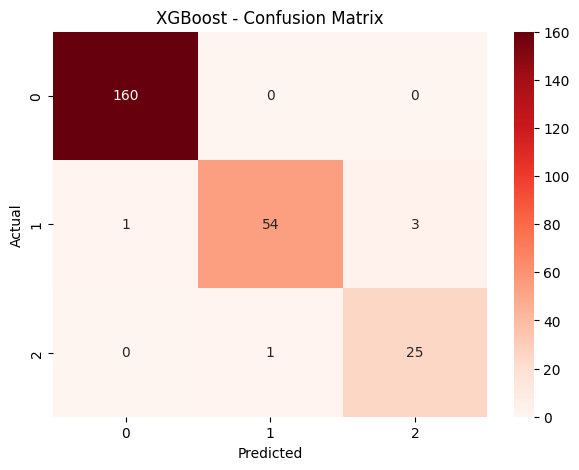

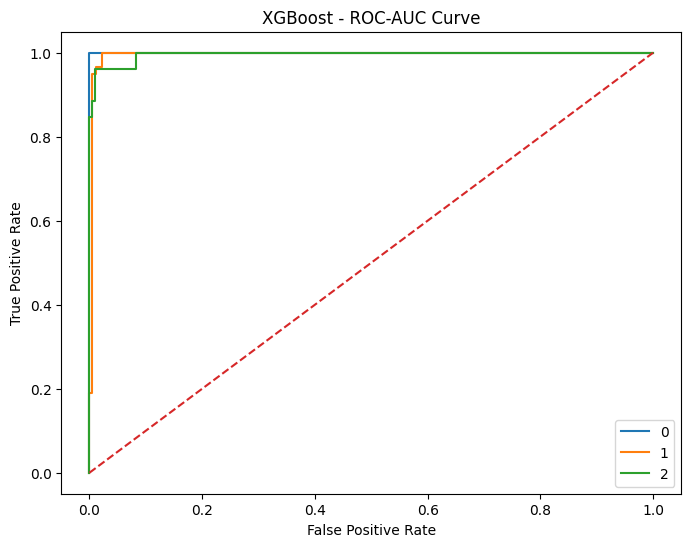

In [37]:
# XGBoost

xgb = XGBClassifier(
    random_state=42,
    eval_metric='mlogloss'
)

xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    xgb,
    xgb_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

model_xgb = xgb_grid.fit(xtrain, ytrain)

# Best Parameters

print("Best Parameters For XGBoost:")
print(model_xgb.best_params_)
print("\n")

# Training Score

print("Training Score For XGBoost :",
      model_xgb.score(xtrain, ytrain) * 100)

# Testing Score

print("Testing Score For XGBoost :",
      model_xgb.score(xtest, ytest) * 100)

# Predictions

ytest_pred = model_xgb.predict(xtest)

# Accuracy Score

accuracy_xgb = accuracy_score(ytest, ytest_pred)

print("Accuracy Score For XGBoost :",
      accuracy_xgb * 100)

print("\n")

# Classification Report

print("Classification Report For XGBoost:")
print(classification_report(ytest, ytest_pred))

# Confusion Matrix

cm_xgb = confusion_matrix(ytest, ytest_pred)

# Sensitivity

sensitivity_xgb = recall_score(
    ytest,
    ytest_pred,
    average='macro'
)

print("Sensitivity :", sensitivity_xgb)

# Specificity

specificity_list = []

for i in range(len(cm_xgb)):

    true_negative = cm_xgb.sum() - (
        cm_xgb[i, :].sum()
        + cm_xgb[:, i].sum()
        - cm_xgb[i, i]
    )

    false_positive = cm_xgb[:, i].sum() - cm_xgb[i, i]

    specificity = true_negative / (
        true_negative + false_positive
    )

    specificity_list.append(specificity)

specificity_xgb = np.mean(specificity_list)

print("Specificity :", specificity_xgb)

# ROC-AUC Score

ytest_probability = model_xgb.predict_proba(xtest)

roc_auc_xgb = roc_auc_score(
    ytest,
    ytest_probability,
    multi_class='ovr',
    average='macro'
)

print("ROC-AUC Score :", roc_auc_xgb)

print("\n")

# Confusion Matrix

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt='d',
    cmap='Reds'
)

plt.title("XGBoost - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC-AUC Curve

ytest_binary = label_binarize(
    ytest,
    classes=model_xgb.classes_
)

plt.figure(figsize=(8, 6))

for i in range(len(model_xgb.classes_)):

    fpr, tpr, _ = roc_curve(
        ytest_binary[:, i],
        ytest_probability[:, i]
    )

    plt.plot(
        fpr,
        tpr,
        label=model_xgb.classes_[i]
    )

plt.plot([0, 1], [0, 1], '--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("XGBoost - ROC-AUC Curve")

plt.legend()
plt.show()